# Lock-up Expiry — does the unlock crash the stock? 🔓
### *180 days after the IPO, insiders can finally sell. Folklore says: short it.*

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Supply--shock sag%3F: Not_supported](https://img.shields.io/badge/Supply--shock_sag%3F-Not_supported-8b949e?style=flat-square)

When a company IPOs, insiders and early investors agree not to sell for ~180 days — the **lock-up**. When that clock runs out, a wave of new shares can hit the market. Supply up, price down… right? Twenty years ago there really was a small sag. We test whether it's still there on a basket of recent IPOs.

> 📓 **This is the plain-language layer.** The statistics, the bootstrap CIs and the cost maths are in the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is generated by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root
sys.path.insert(0, os.path.abspath(".."))         # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
from lockup_expiry import data, strategy as st

# Real-tape headline numbers (mirror docs/results.md; as-of 2026-06-18).
HEADLINE = {'as_of': '2026-06-18', 'fingerprint': '7bec0a409224', 'n_events': 29, 'aar0_bps': 62.9, 'aar0_t': 0.87, 'runup_bps': -316.7, 'runup_t': -1.98, 'tight_bps': 74.2, 'tight_t': 0.56, 'post_bps': 322.7, 'post_t': 1.75, 'wide_bps': 6.0, 'wide_t': 0.02, 'short_gross_bps': -322.7, 'short_t': -1.75, 'short_net10_bps': -362.7}

def load_tape():
    """Try the real cached panel; fall back to the synthetic null tape OFFLINE."""
    try:
        panel = data.fetch_event_panel(fetch=False)
        if panel.empty:
            raise RuntimeError("empty cache")
        return panel, "REAL"
    except Exception as e:
        panel, _ = data.synthetic_panel(n_events=30, sag_bps=0.0, seed=319)
        return panel, "SYNTHETIC"


## The answer first 🎯

| Question | Answer |
|---|---|
| Does the price sag when the lock-up expires? | **No** — on a 2019–2024 basket the abnormal return at the unlock is flat-to-*positive*. |
| Can you short the unlock for profit? | **No** — the folklore short loses money *before* costs; stocks tend to drift *up* vs the market just after. |
| Wasn't this a real effect? | **It was** (≈ −1.5% in 2001 studies) — but the date is in the prospectus, known months ahead, so it got arbitraged away. |

On the real tape (as-of 2026-06-18, 29 IPOs): the expiry-day abnormal return is **+63 bps** (*t* = +0.87) — not even negative.

## 1 · The claim

> *"180 days after an IPO the lock-up expires and insiders dump their shares. The supply flood pushes the price down — a predictable, calendar-known sag. Short the stock into the unlock."*

It's a clean story and it has academic roots: **Field & Hanka (2001)** found a roughly **−1.5%** abnormal return in the days around expiry, bigger for venture-backed firms, with a permanent jump in trading volume.

## 2 · So what?

If true, it's a rare thing: a **date you know in advance** with a directional edge. No earnings surprise to predict, no macro call — just a calendar entry. That's exactly why it's suspicious: anything every trader can see coming tends to get priced in *before* it happens. If the sag is real and persistent, markets are leaving money on a known table; if it's gone, that's efficiency doing its job.

## 3 · How would we even know?

We run an **event study**. For each IPO we line up its returns *relative to the market* (stock minus SPY — so a general bull market doesn't fool us) around the unlock date, calling the expiry day `tau = 0`. Then we average across IPOs and look for a dip near `tau = 0`.

**What would make us say "mirage":** if the average abnormal return at and after the unlock is *not significantly negative* — especially if it's flat or positive.

## 4 · The teardown — let's actually look

First, the picture: average abnormal return at each day around the unlock.

Tape in this cell: REAL  (REAL = cached IPO basket; SYNTHETIC = offline null)


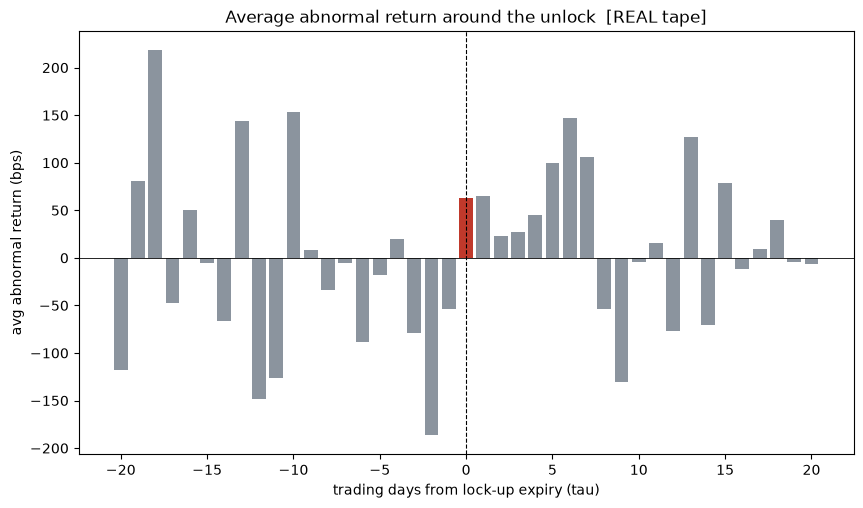

If the folklore were right, tau=0 (red) and the bars just after it would dip well below zero.


In [2]:
panel, tape = load_tape()
print(f'Tape in this cell: {tape}  (REAL = cached IPO basket; SYNTHETIC = offline null)')
a = st.aar(panel)
fig, ax = plt.subplots()
ax.bar(a['tau'], a['aar']*1e4, color=np.where(a['tau']==0,'#c0392b','#8b949e'))
ax.axvline(0, color='k', lw=0.8, ls='--')
ax.axhline(0, color='k', lw=0.6)
ax.set_xlabel('trading days from lock-up expiry (tau)')
ax.set_ylabel('avg abnormal return (bps)')
ax.set_title(f'Average abnormal return around the unlock  [{tape} tape]')
plt.show()
print('If the folklore were right, tau=0 (red) and the bars just after it would dip well below zero.')

On the **real** basket, the bar at the unlock isn't a crater — it's flat-to-positive. Here are the actual numbers from the pinned run (these come from `docs/results.md`, the real tape):

In [3]:
rows = [
    ('expiry day (tau=0)', HEADLINE['aar0_bps'], HEADLINE['aar0_t']),
    ('run-up  [-5,-1]',    HEADLINE['runup_bps'], HEADLINE['runup_t']),
    ('tight   [-1,+1]',    HEADLINE['tight_bps'], HEADLINE['tight_t']),
    ('post    [0,+5]',     HEADLINE['post_bps'],  HEADLINE['post_t']),
    ('wide    [-5,+5]',    HEADLINE['wide_bps'],  HEADLINE['wide_t']),
]
tbl = pd.DataFrame(rows, columns=['window','mean_abnormal_bps','HAC_t'])
print(f"REAL tape (as-of {HEADLINE['as_of']}, {HEADLINE['n_events']} IPOs):")
print(tbl.to_string(index=False))
print('\nNot one window is a significant negative sag. The post-expiry window is *positive*.')

REAL tape (as-of 2026-06-18, 29 IPOs):
            window  mean_abnormal_bps  HAC_t
expiry day (tau=0)              62.90   0.87
   run-up  [-5,-1]            -316.70  -1.98
   tight   [-1,+1]              74.20   0.56
    post    [0,+5]             322.70   1.75
   wide    [-5,+5]               6.00   0.02

Not one window is a significant negative sag. The post-expiry window is *positive*.


## 5 · The verdict

- **Signal — None.** No window around the unlock is a significant negative sag. The expiry day is +63 bps; the days after are *up*; the only down window (the 5-day run-up) can't clear the significance bar.
- **Tradability — Mirage.** Shorting the unlock loses money before you pay a cent.
- **A predictable supply-shock sag? — Not supported.** It was real in 2001; the market learned the date and arbitraged it away.

## 6 · Could you actually trade it?

The believers' trade is *short the stock over the days after the unlock* (hedged with the market). On the real basket that short **loses** ~323 bps gross — the wrong direction entirely. And you'd be shorting a *recent IPO*: those are often hard-to-borrow, with fat borrow fees on top. The one window that leans the right way (front-running the run-up) gets eaten by paying costs on *two* legs (the stock and the hedge).

## 7 · Going further 🚪

- **VC-backed vs not.** Field & Hanka found the sag concentrated in venture-backed firms — tag the basket and split.
- **Size of the unlock.** The sag should scale with the *fraction* of shares unlocking; that data lives in S-1 filings.
- **Survivorship.** Our basket only has survivors. The worst post-unlock collapses may be in names that later delisted — add them and the picture could shift.
- **Fork it:** swap the basket, change the lock-up convention, or fit a real market-model beta instead of beta = 1.